<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/PhysicalPropertiesOfMethanol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physical properties of methanol with NeqSim

**Audience.** Process, production, flow-assurance, and equipment engineers who need transparent methanol-property calculations for hydraulic and heat-transfer screening.

**Prerequisites.** Basic thermodynamics, SI units, and introductory Python. No previous NeqSim experience is required.

**Learning objectives.** By the end, you will be able to:

1. distinguish equilibrium, caloric, and transport properties;
2. explain why the CPA model is used for hydrogen-bonding methanol;
3. calculate density, heat capacities, viscosity, conductivity, and speed of sound;
4. verify compressibility and sound speed with independent identities;
5. study temperature, pressure, and water-content sensitivities;
6. use NeqSim properties in pipe-flow and heat-transfer correlations; and
7. pass a methanol state through named streams and a heater in a reusable process model.

This is an educational screening workflow, not a certified design or safety calculation.

In [1]:
import importlib.util
import subprocess
import sys


if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "neqsim",
        ]
    )

## 1. Scope, calculation chain, and units

The notebook follows a reusable engineering chain:

`composition -> thermodynamic system -> TP flash -> initialized properties -> engineering use -> checks`

Pressure is absolute. Temperatures are in K; pressure in bara; density in kg/m³; dynamic viscosity in Pa s; thermal conductivity in W/(m K); heat capacity in J/(kg K); and speed in m/s. Pipe calculations use m, s, Pa, W, and kg throughout.

The setup cell installs the current PyPI package only when it is absent. It does not restart the runtime or depend on local files, credentials, or proprietary data.

In [2]:
from importlib.metadata import version
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim


NEQSIM_VERSION = version("neqsim")
REFERENCE_TEMPERATURE_K = 298.15
REFERENCE_PRESSURE_BARA = 1.01325
NIST_BOILING_TEMPERATURE_K = 337.8
REFERENCE_DENSITY_KG_PER_M3 = 786.6
REFERENCE_CP_J_PER_MOL_K = 80.35
METHANOL_MOLAR_MASS_KG_PER_MOL = 0.032042

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.5f}")

print(f"NeqSim version [-]: {NEQSIM_VERSION}")
print("Reference state: 298.15 K and 1.01325 bara")

NeqSim version [-]: 3.16.0
Reference state: 298.15 K and 1.01325 bara


## 2. Property families and governing ideas

Equilibrium properties determine phases and composition. Caloric properties such as $C_p$ and enthalpy quantify energy response. Transport properties such as viscosity $\mu$ and thermal conductivity $k$ govern momentum and heat transfer.

Density is mass per volume:

$$
\rho = \frac{m}{V}
$$

The isobaric heat capacity is:

$$
C_p = \left(\frac{\partial h}{\partial T}\right)_P
$$

Here $\rho$ is density in kg/m³, $m$ is mass in kg, $V$ is volume in m³, $h$ is specific enthalpy in J/kg, and $T$ is temperature in K. A thermodynamic equation of state and a transport correlation answer different questions, so one successful benchmark does not validate every property.

In [3]:
def create_cpa_fluid(temperature_k, pressure_bara, methanol_moles, water_moles=0.0):
    fluid = jneqsim.thermo.system.SystemSrkCPAstatoil(
        temperature_k,
        pressure_bara,
    )
    fluid.addComponent("methanol", methanol_moles)

    if water_moles > 0.0:
        fluid.addComponent("water", water_moles)

    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    return fluid


def flash_and_initialize(fluid):
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    fluid.initPhysicalProperties()
    return fluid


reference_fluid = create_cpa_fluid(
    REFERENCE_TEMPERATURE_K,
    REFERENCE_PRESSURE_BARA,
    1.0,
)
flash_and_initialize(reference_fluid)

print("Reference fluid built and flashed successfully.")

Reference fluid built and flashed successfully.


## 3. How NeqSim represents methanol

The thermodynamic system stores the model, components, mole amounts, temperature, pressure, phase settings, and calculated phase state. `SystemSrkCPAstatoil` combines the Soave-Redlich-Kwong cubic reference with an association term. Methanol forms hydrogen bonds, so CPA is a more defensible starting point than an unassociated cubic model for liquid properties and methanol-water mixtures.

Mixing-rule code 10 activates the established CPA mixing rule. `setMultiPhaseCheck(True)` allows phase splitting. A TP flash solves equilibrium at fixed temperature, pressure, and total composition; `initProperties()` and `initPhysicalProperties()` then prepare caloric and transport results.

NeqSim labels the associating liquid phase `aqueous`, even when the component inventory is pure methanol. Code should inspect composition as well as the phase label.

In [4]:
reference_phase = reference_fluid.getPhase(0)
reference_component = reference_phase.getComponent("methanol")

component_table = pd.Series(
    {
        "component": str(reference_component.getComponentName()),
        "molar mass [kg/mol]": reference_component.getMolarMass(),
        "critical temperature [K]": reference_component.getTC(),
        "critical pressure [bara]": reference_component.getPC(),
        "phase count [-]": reference_fluid.getNumberOfPhases(),
        "phase label": str(reference_phase.getPhaseTypeName()),
        "methanol mole fraction [-]": reference_phase.getComponent(
            "methanol"
        ).getx(),
    },
    name="NeqSim system inspection",
)
component_table

component                     methanol
molar mass [kg/mol]            0.03204
critical temperature [K]     512.64000
critical pressure [bara]      80.96000
phase count [-]                      1
phase label                    aqueous
methanol mole fraction [-]     1.00000
Name: NeqSim system inspection, dtype: object

## 4. A reusable property extractor

The helper below returns one explicit row per state. It keeps units in column names and avoids relying on hidden phase indices beyond the confirmed single-liquid region used here.

Dynamic viscosity relates shear stress to velocity gradient. Thermal conductivity relates heat flux to temperature gradient. Their constitutive forms are:

$$
\tau = \mu \frac{\mathrm{d}u}{\mathrm{d}y}
$$

$$
q'' = -k \frac{\mathrm{d}T}{\mathrm{d}x}
$$

Here $\tau$ is shear stress in Pa, $u$ is velocity in m/s, $y$ and $x$ are distances in m, and $q''$ is heat flux in W/m². Transport results come from NeqSim physical-property models initialized after the flash.

In [5]:
def extract_liquid_properties(fluid):
    phase = fluid.getPhase(0)
    viscosity_pa_s = phase.getViscosity("kg/msec")
    density_kg_per_m3 = phase.getDensity("kg/m3")
    cp_j_per_kg_k = phase.getCp("J/kgK")
    conductivity_w_per_m_k = phase.getThermalConductivity("W/mK")

    return {
        "temperature [K]": fluid.getTemperature("K"),
        "pressure [bara]": fluid.getPressure("bara"),
        "phase count [-]": fluid.getNumberOfPhases(),
        "phase label": str(phase.getPhaseTypeName()),
        "density [kg/m3]": density_kg_per_m3,
        "Cp [J/(kg K)]": cp_j_per_kg_k,
        "Cv [J/(kg K)]": phase.getCv("J/kgK"),
        "viscosity [mPa s]": 1000.0 * viscosity_pa_s,
        "conductivity [W/(m K)]": conductivity_w_per_m_k,
        "sound speed [m/s]": phase.getSoundSpeed(),
        "kinematic viscosity [m2/s]": viscosity_pa_s / density_kg_per_m3,
        "thermal diffusivity [m2/s]": (
            conductivity_w_per_m_k / (density_kg_per_m3 * cp_j_per_kg_k)
        ),
        "Prandtl number [-]": (
            viscosity_pa_s * cp_j_per_kg_k / conductivity_w_per_m_k
        ),
    }


reference_properties = pd.Series(
    extract_liquid_properties(reference_fluid),
    name="CPA methanol at the reference state",
)
reference_properties

temperature [K]                298.15000
pressure [bara]                  1.01325
phase count [-]                        1
phase label                      aqueous
density [kg/m3]                792.62686
Cp [J/(kg K)]                2,271.42689
Cv [J/(kg K)]                1,914.08729
viscosity [mPa s]                0.50671
conductivity [W/(m K)]           0.19793
sound speed [m/s]            1,029.45460
kinematic viscosity [m2/s]       0.00000
thermal diffusivity [m2/s]       0.00000
Prandtl number [-]               5.81501
Name: CPA methanol at the reference state, dtype: object

## 5. Independent ambient-property benchmarks

Public reference values provide an evidence check rather than a tuning target. At 298.15 K, the reference liquid density is 786.6 kg/m³. NIST reports $C_p = 80.35$ J/(mol K), converted with methanol molar mass:

$$
C_{p,\mathrm{mass}} = \frac{C_{p,\mathrm{molar}}}{M}
$$

$M$ is molar mass in kg/mol. CPA predicts density within about one percent here. Its heat-capacity error is larger, illustrating that phase behavior, density, caloric properties, and transport properties have separate uncertainty.

The benchmark state and reference provenance must match. A value at the normal boiling point, elevated pressure, or another purity cannot be silently compared with 298.15 K and atmospheric pressure.

In [6]:
reference_cp_j_per_kg_k = (
    REFERENCE_CP_J_PER_MOL_K / METHANOL_MOLAR_MASS_KG_PER_MOL
)
calculated_density = reference_properties["density [kg/m3]"]
calculated_cp = reference_properties["Cp [J/(kg K)]"]

benchmark_table = pd.DataFrame(
    [
        {
            "property": "liquid density",
            "NeqSim value": calculated_density,
            "reference value": REFERENCE_DENSITY_KG_PER_M3,
            "unit": "kg/m3",
            "relative deviation [%]": 100.0
            * (calculated_density / REFERENCE_DENSITY_KG_PER_M3 - 1.0),
        },
        {
            "property": "isobaric heat capacity",
            "NeqSim value": calculated_cp,
            "reference value": reference_cp_j_per_kg_k,
            "unit": "J/(kg K)",
            "relative deviation [%]": 100.0
            * (calculated_cp / reference_cp_j_per_kg_k - 1.0),
        },
    ]
).set_index("property")
benchmark_table

,NeqSim value,reference value,unit,relative deviation [%]
property,,,,
liquid density,792.62686,786.60000,kg/m3,0.76619
isobaric heat capacity,"2,271.42689","2,507.64621",J/(kg K),-9.41996


## 6. Thermal expansion and isothermal compressibility

Two useful response properties are evaluated with centered finite differences:

$$
\alpha_P = -\frac{1}{\rho}\left(\frac{\partial \rho}{\partial T}\right)_P
$$

$$
\kappa_T = \frac{1}{\rho}\left(\frac{\partial \rho}{\partial P}\right)_T
$$

$\alpha_P$ is isobaric thermal expansion in 1/K, and $\kappa_T$ is isothermal compressibility in 1/Pa. The pressure derivative is positive because liquid density normally rises with pressure. Small symmetric steps reduce first-order truncation error while remaining large enough to avoid numerical noise.

In [7]:
def liquid_density(temperature_k, pressure_bara):
    fluid = create_cpa_fluid(temperature_k, pressure_bara, 1.0)
    flash_and_initialize(fluid)
    return fluid.getPhase(0).getDensity("kg/m3")


temperature_step_k = 0.10
pressure_step_bara = 1.00
rho_reference = liquid_density(
    REFERENCE_TEMPERATURE_K,
    REFERENCE_PRESSURE_BARA,
)
rho_temperature_low = liquid_density(
    REFERENCE_TEMPERATURE_K - temperature_step_k,
    REFERENCE_PRESSURE_BARA,
)
rho_temperature_high = liquid_density(
    REFERENCE_TEMPERATURE_K + temperature_step_k,
    REFERENCE_PRESSURE_BARA,
)
rho_pressure_low = liquid_density(
    REFERENCE_TEMPERATURE_K,
    REFERENCE_PRESSURE_BARA,
)
rho_pressure_high = liquid_density(
    REFERENCE_TEMPERATURE_K,
    REFERENCE_PRESSURE_BARA + pressure_step_bara,
)

density_temperature_slope = (
    rho_temperature_high - rho_temperature_low
) / (2.0 * temperature_step_k)
density_pressure_slope = (
    rho_pressure_high - rho_pressure_low
) / (pressure_step_bara * 1.0e5)
thermal_expansion_per_k = -density_temperature_slope / rho_reference
compressibility_per_pa = density_pressure_slope / rho_reference

response_table = pd.Series(
    {
        "thermal expansion [1/K]": thermal_expansion_per_k,
        "finite-difference compressibility [1/Pa]": compressibility_per_pa,
        "NeqSim compressibility [1/Pa]": (
            reference_phase.getIsothermalCompressibility() / 1.0e5
        ),
    },
    name="Liquid response properties",
)
response_table

thermal expansion [1/K]                    0.00116
finite-difference compressibility [1/Pa]   0.00000
NeqSim compressibility [1/Pa]              0.00000
Name: Liquid response properties, dtype: float64

## 7. Sound speed as a thermodynamic consistency check

For a single-phase fluid, isentropic compressibility and sound speed satisfy:

$$
c^2 = \frac{1}{\rho \kappa_S}
$$

The heat-capacity identity gives $\kappa_S = \kappa_T C_v/C_p$. Combining them yields an independent reconstruction:

$$
c = \sqrt{\frac{C_p}{\rho \kappa_T C_v}}
$$

$c$ is sound speed in m/s, $\kappa_S$ and $\kappa_T$ are in 1/Pa, and $C_p$ and $C_v$ use the same mass basis. Agreement tests internal thermodynamic consistency; it is not an experimental validation of the absolute sound speed.

In [8]:
cp_mass = reference_phase.getCp("J/kgK")
cv_mass = reference_phase.getCv("J/kgK")
neqsim_compressibility_per_pa = (
    reference_phase.getIsothermalCompressibility() / 1.0e5
)
sound_speed_reported = reference_phase.getSoundSpeed()
sound_speed_reconstructed = np.sqrt(
    cp_mass
    / (
        reference_phase.getDensity("kg/m3")
        * neqsim_compressibility_per_pa
        * cv_mass
    )
)
sound_speed_relative_residual = (
    sound_speed_reconstructed / sound_speed_reported - 1.0
)

sound_speed_table = pd.Series(
    {
        "reported sound speed [m/s]": sound_speed_reported,
        "reconstructed sound speed [m/s]": sound_speed_reconstructed,
        "relative residual [-]": sound_speed_relative_residual,
        "Cp/Cv [-]": cp_mass / cv_mass,
    },
    name="Sound-speed consistency",
)
sound_speed_table

reported sound speed [m/s]        1,029.45460
reconstructed sound speed [m/s]   1,029.45460
relative residual [-]                 0.00000
Cp/Cv [-]                             1.18669
Name: Sound-speed consistency, dtype: float64

## 8. Temperature sensitivity below the normal boiling point

The sweep covers 280-330 K at 1.01325 bara, remaining below the experimental normal boiling temperature of approximately 337.8 K. In this liquid region, density, viscosity, conductivity, and sound speed are expected to decrease as temperature rises. Heat capacity generally rises.

These trends have direct consequences: a warmer liquid occupies more volume, has lower viscous pressure loss at a fixed velocity, and changes the Reynolds and Prandtl numbers. The endpoints are scenario choices, not an assertion that every industrial methanol service operates in this range.

In [9]:
temperature_values_k = np.array([280.0, 290.0, 298.15, 310.0, 320.0, 330.0])
temperature_rows = []

for temperature_k in temperature_values_k:
    temperature_fluid = create_cpa_fluid(
        temperature_k,
        REFERENCE_PRESSURE_BARA,
        1.0,
    )
    flash_and_initialize(temperature_fluid)
    temperature_rows.append(extract_liquid_properties(temperature_fluid))

temperature_table = pd.DataFrame(temperature_rows).set_index("temperature [K]")
temperature_table[
    [
        "density [kg/m3]",
        "viscosity [mPa s]",
        "conductivity [W/(m K)]",
        "Cp [J/(kg K)]",
        "sound speed [m/s]",
    ]
]

,density [kg/m3],viscosity [mPa s],conductivity [W/(m K)],Cp [J/(kg K)],sound speed [m/s]
temperature [K],,,,,
280.00000,808.95590,0.65376,0.20106,"2,112.03632","1,091.84385"
290.00000,800.03901,0.56415,0.19931,"2,198.45781","1,057.02250"
298.15000,792.62686,0.50671,0.19793,"2,271.42689","1,029.45460"
310.00000,781.57863,0.44041,0.19601,"2,381.11375",990.44791
320.00000,771.96545,0.39557,0.19447,"2,476.64132",958.32943
330.00000,762.04378,0.35775,0.19300,"2,574.65529",926.76400


## 9. Reading the temperature-property plots

The plot uses separate panels because the properties have different dimensions and numerical scales. A falling viscosity usually raises Reynolds number at fixed density, speed, and diameter. A falling conductivity can reduce a convective heat-transfer coefficient if other dimensionless groups stay fixed.

Never extrapolate a smooth plot through a phase boundary or to the critical region without a stability calculation and appropriate validation. The normal boiling point is marked to show why this atmospheric-pressure sweep stops at 330 K.

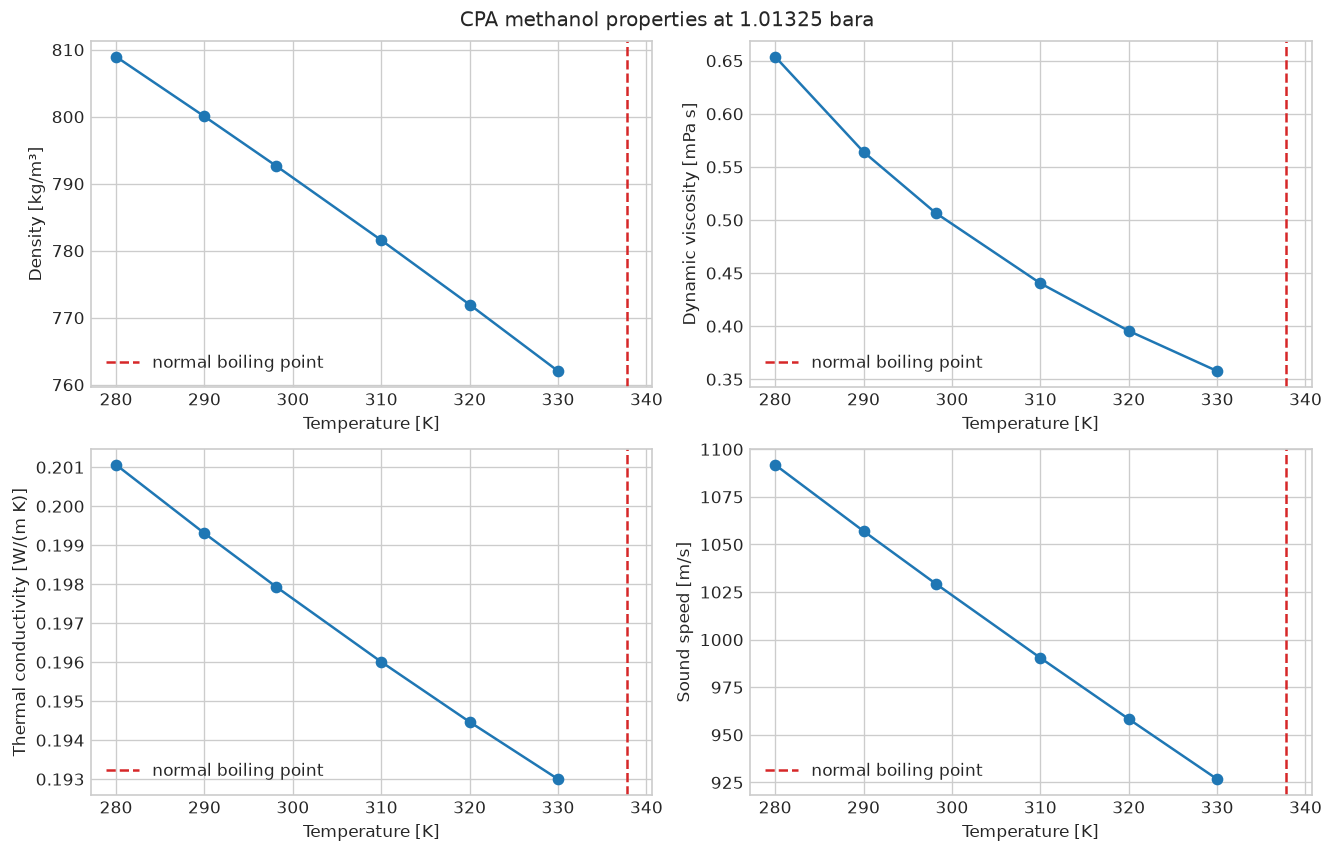

In [10]:
figure, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
plot_specs = [
    ("density [kg/m3]", "Density [kg/m³]"),
    ("viscosity [mPa s]", "Dynamic viscosity [mPa s]"),
    ("conductivity [W/(m K)]", "Thermal conductivity [W/(m K)]"),
    ("sound speed [m/s]", "Sound speed [m/s]"),
]

for axis, (column_name, y_label) in zip(axes.flat, plot_specs):
    axis.plot(
        temperature_table.index,
        temperature_table[column_name],
        marker="o",
    )
    axis.axvline(
        NIST_BOILING_TEMPERATURE_K,
        color="tab:red",
        linestyle="--",
        label="normal boiling point",
    )
    axis.set_xlabel("Temperature [K]")
    axis.set_ylabel(y_label)
    axis.legend()

figure.suptitle("CPA methanol properties at 1.01325 bara")
plt.show()

## 10. Pressure sensitivity of the compressed liquid

At 298.15 K, methanol remains a compressed liquid from atmospheric pressure to 100 bara in this scenario. Density and sound speed should increase with pressure, while the response is much weaker than the temperature effect over the preceding ranges.

The pressure series also checks that repeated flashes are stable. CPA can represent thermodynamic compression, while the shown pure-component thermal-conductivity correlation is nearly pressure independent over this range. High-pressure design work should be compared with dedicated reference correlations and applicable experimental data.

In [11]:
pressure_values_bara = np.array([1.01325, 10.0, 25.0, 50.0, 100.0])
pressure_rows = []

for pressure_bara in pressure_values_bara:
    pressure_fluid = create_cpa_fluid(
        REFERENCE_TEMPERATURE_K,
        pressure_bara,
        1.0,
    )
    flash_and_initialize(pressure_fluid)
    pressure_rows.append(extract_liquid_properties(pressure_fluid))

pressure_table = pd.DataFrame(pressure_rows).set_index("pressure [bara]")
pressure_table[
    [
        "density [kg/m3]",
        "viscosity [mPa s]",
        "Cp [J/(kg K)]",
        "sound speed [m/s]",
    ]
]

,density [kg/m3],viscosity [mPa s],Cp [J/(kg K)],sound speed [m/s]
pressure [bara],,,,
1.01325,792.62686,0.50671,"2,271.42689","1,029.45460"
10.00000,793.62682,0.50879,"2,269.58420","1,035.66078"
25.00000,795.26825,0.51218,"2,266.59847","1,045.94173"
50.00000,797.93051,0.51774,"2,261.85651","1,062.86951"
100.00000,803.00018,0.52872,"2,253.15609","1,096.00703"


## 11. Water content and mixture properties

Commercial methanol can contain water, and water uptake is important in solvent regeneration and injection systems. The composition sweep uses one total mole, with methanol mole fraction $x_m$ and water mole fraction $x_w$:

$$
x_m + x_w = 1
$$

CPA represents self-association and cross-association, making it suitable for this qualitative methanol-water study. The sweep is at 298.15 K and 1.01325 bara and is verified to remain a single associating liquid phase. Mixture transport correlations still require application-specific validation.

In [12]:
methanol_mole_fractions = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
mixture_rows = []

for methanol_mole_fraction in methanol_mole_fractions:
    water_mole_fraction = 1.0 - methanol_mole_fraction
    mixture_fluid = create_cpa_fluid(
        REFERENCE_TEMPERATURE_K,
        REFERENCE_PRESSURE_BARA,
        max(methanol_mole_fraction, 1.0e-12),
        max(water_mole_fraction, 1.0e-12),
    )
    flash_and_initialize(mixture_fluid)
    mixture_properties = extract_liquid_properties(mixture_fluid)
    mixture_properties["methanol mole fraction [-]"] = methanol_mole_fraction
    mixture_properties["water mole fraction [-]"] = water_mole_fraction
    mixture_rows.append(mixture_properties)

mixture_table = pd.DataFrame(mixture_rows).set_index(
    "methanol mole fraction [-]"
)
mixture_table[
    [
        "water mole fraction [-]",
        "density [kg/m3]",
        "viscosity [mPa s]",
        "conductivity [W/(m K)]",
        "Prandtl number [-]",
    ]
]

,water mole fraction [-],density [kg/m3],viscosity [mPa s],conductivity [W/(m K)],Prandtl number [-]
methanol mole fraction [-],,,,,
0.00000,1.00000,994.99704,0.89157,0.61504,5.29356
0.25000,0.75000,924.49509,0.72247,0.45979,5.10952
0.50000,0.50000,872.29827,0.62098,0.34804,5.16498
0.75000,0.25000,829.78111,0.55397,0.26376,5.39991
1.00000,0.00000,792.62686,0.50671,0.19793,5.81501


## 12. Engineering interpretation of water contamination

The calculated mixture becomes denser, more viscous, and more thermally conductive as water fraction rises. Those changes affect pump hydraulics and heat exchange simultaneously. Treating wet methanol as pure methanol can therefore bias both pressure-drop and duty estimates.

This grid is intentionally coarse and meant for screening. A project model should use measured composition, validate density and viscosity over the actual temperature range, and consider salts or other contaminants separately. Electrolytes, corrosion, reaction, and solids are outside this simple binary system.

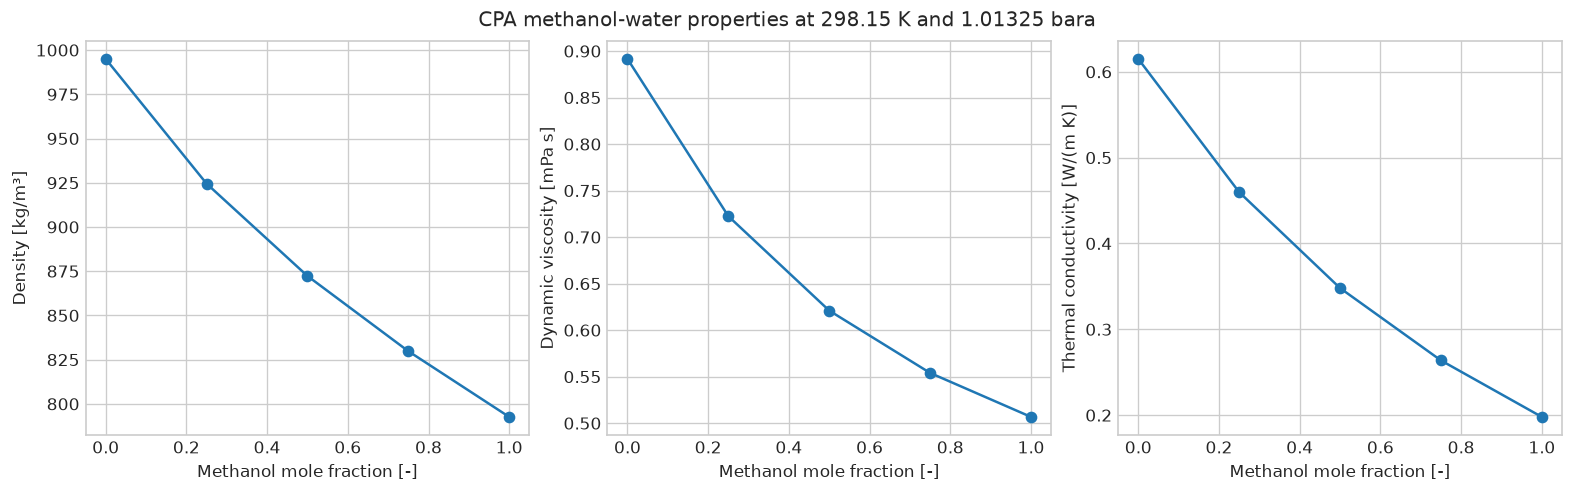

In [13]:
figure, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
mixture_plot_specs = [
    ("density [kg/m3]", "Density [kg/m³]"),
    ("viscosity [mPa s]", "Dynamic viscosity [mPa s]"),
    ("conductivity [W/(m K)]", "Thermal conductivity [W/(m K)]"),
]

for axis, (column_name, y_label) in zip(axes, mixture_plot_specs):
    axis.plot(
        mixture_table.index,
        mixture_table[column_name],
        marker="o",
    )
    axis.set_xlabel("Methanol mole fraction [-]")
    axis.set_ylabel(y_label)

figure.suptitle("CPA methanol-water properties at 298.15 K and 1.01325 bara")
plt.show()

## 13. From properties to pipe-flow screening

For a circular pipe, the principal dimensionless groups are:

$$
\mathrm{Re} = \frac{\rho u D}{\mu}
$$

$$
\mathrm{Pr} = \frac{\mu C_p}{k}
$$

$u$ is mean velocity in m/s and $D$ is inside diameter in m. For smooth turbulent flow, the Blasius and Dittus-Boelter screening correlations are:

$$
f_D = 0.3164\,\mathrm{Re}^{-0.25}
$$

$$
\mathrm{Nu} = 0.023\,\mathrm{Re}^{0.8}\mathrm{Pr}^{0.4}
$$

The Darcy pressure loss is $\Delta P=f_D(L/D)\rho u^2/2$, and $h=\mathrm{Nu}k/D$. These correlations are educational approximations for fully developed turbulent flow, a smooth pipe, and heating of the fluid.

In [14]:
def pipe_screening(properties, velocity_m_per_s, diameter_m, length_m):
    density = properties["density [kg/m3]"]
    viscosity = properties["viscosity [mPa s]"] / 1000.0
    conductivity = properties["conductivity [W/(m K)]"]
    cp_mass = properties["Cp [J/(kg K)]"]

    reynolds_number = density * velocity_m_per_s * diameter_m / viscosity
    prandtl_number = viscosity * cp_mass / conductivity
    darcy_friction_factor = 0.3164 * reynolds_number ** (-0.25)
    pressure_drop_pa = (
        darcy_friction_factor
        * length_m
        / diameter_m
        * density
        * velocity_m_per_s**2
        / 2.0
    )
    nusselt_number = (
        0.023 * reynolds_number**0.8 * prandtl_number**0.4
    )
    heat_transfer_coefficient = nusselt_number * conductivity / diameter_m

    return {
        "velocity [m/s]": velocity_m_per_s,
        "Reynolds number [-]": reynolds_number,
        "Prandtl number [-]": prandtl_number,
        "Darcy friction factor [-]": darcy_friction_factor,
        "pressure drop [bar]": pressure_drop_pa / 1.0e5,
        "Nusselt number [-]": nusselt_number,
        "heat-transfer coefficient [W/(m2 K)]": heat_transfer_coefficient,
    }


base_pipe_result = pd.Series(
    pipe_screening(
        reference_properties,
        velocity_m_per_s=1.5,
        diameter_m=0.050,
        length_m=100.0,
    ),
    name="50 mm ID, 100 m smooth-pipe screen",
)
base_pipe_result

velocity [m/s]                               1.50000
Reynolds number [-]                    117,320.08775
Prandtl number [-]                           5.81501
Darcy friction factor [-]                    0.01710
pressure drop [bar]                          0.30489
Nusselt number [-]                         528.50108
heat-transfer coefficient [W/(m2 K)]     2,092.09766
Name: 50 mm ID, 100 m smooth-pipe screen, dtype: float64

## 14. Velocity sensitivity and correlation limits

Velocity has a strong nonlinear effect. The Darcy-Weisbach term contains $u^2$, while the friction factor also changes with Reynolds number. The heat-transfer coefficient rises because the Nusselt number scales approximately with $\mathrm{Re}^{0.8}$ in the selected correlation.

The sweep is valid only where $\mathrm{Re}$ is comfortably turbulent. Real design must include roughness, fittings, elevation, inlet development, wall conditions, fouling, heat loss, phase change, and pump operating limits. A rigorous NeqSim pipeline unit should replace this screen when those effects matter.

,Reynolds number [-],Prandtl number [-],Darcy friction factor [-],pressure drop [bar],Nusselt number [-],heat-transfer coefficient [W/(m2 K)]
velocity [m/s],,,,,,
0.50000,"39,106.69592",5.81501,0.02250,0.04458,219.45672,868.73026
1.00000,"78,213.39183",5.81501,0.01892,0.14996,382.09634,"1,512.54724"
1.50000,"117,320.08775",5.81501,0.01710,0.30489,528.50108,"2,092.09766"
2.00000,"156,426.78366",5.81501,0.01591,0.50441,665.26836,"2,633.49770"
2.50000,"195,533.47958",5.81501,0.01505,0.74538,795.28883,"3,148.19013"


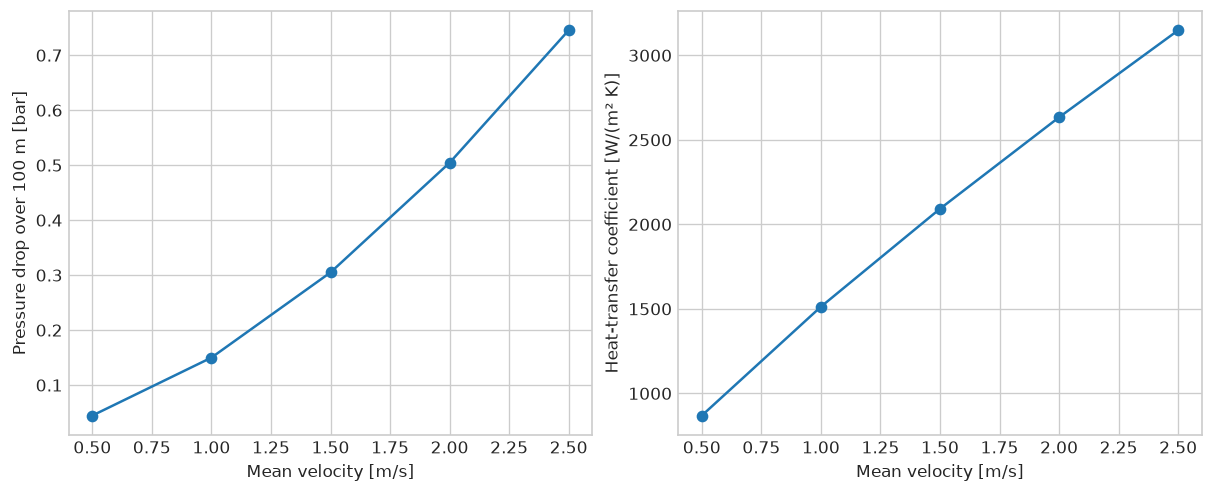

In [15]:
velocity_values_m_per_s = np.array([0.5, 1.0, 1.5, 2.0, 2.5])
hydraulic_rows = []

for velocity_m_per_s in velocity_values_m_per_s:
    hydraulic_rows.append(
        pipe_screening(
            reference_properties,
            velocity_m_per_s=velocity_m_per_s,
            diameter_m=0.050,
            length_m=100.0,
        )
    )

hydraulic_table = pd.DataFrame(hydraulic_rows).set_index("velocity [m/s]")

figure, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].plot(
    hydraulic_table.index,
    hydraulic_table["pressure drop [bar]"],
    marker="o",
)
axes[0].set_xlabel("Mean velocity [m/s]")
axes[0].set_ylabel("Pressure drop over 100 m [bar]")
axes[1].plot(
    hydraulic_table.index,
    hydraulic_table["heat-transfer coefficient [W/(m2 K)]"],
    marker="o",
)
axes[1].set_xlabel("Mean velocity [m/s]")
axes[1].set_ylabel("Heat-transfer coefficient [W/(m² K)]")
plt.show()

hydraulic_table

## 15. Composable streams and a heater

NeqSim separates thermodynamic state from process topology. The fluid contains CPA, composition, $T$, and $P$. A `Stream` adds a name and flow rate. A `Heater` clones its inlet state and solves the specified outlet temperature. A `ProcessSystem` executes the connected units in order.

The example heats 5000 kg/h of liquid methanol from 298.15 K to 320 K at 5 bara. That state remains liquid. Named streams can be connected later to pumps, exchangers, separators, or a larger process model.

In [16]:
process_fluid = create_cpa_fluid(298.15, 5.0, 1.0)
feed_stream = jneqsim.process.equipment.stream.Stream(
    "methanol feed",
    process_fluid,
)
feed_stream.setFlowRate(5000.0, "kg/hr")

heater = jneqsim.process.equipment.heatexchanger.Heater(
    "methanol heater",
    feed_stream,
)
heater.setOutTemperature(320.0, "K")

process_system = jneqsim.process.processmodel.ProcessSystem()
process_system.add(feed_stream)
process_system.add(heater)
process_system.run()

outlet_stream = heater.getOutletStream()
outlet_stream.run()

print("Methanol heater process executed successfully.")

Methanol heater process executed successfully.


## 16. Heater balance and changing properties

For a steady heater with no shaft work and negligible kinetic and potential energy change:

$$
\dot Q = \dot m\left(h_2-h_1\right)
$$

$\dot Q$ is duty in kW, $\dot m$ is mass flow in kg/s, and $h$ is specific enthalpy in kJ/kg. The same run also shows that downstream density and viscosity belong to the outlet state; they should not be copied from the inlet.

The heater object calculates thermodynamic duty. Exchanger area, utility temperature, pressure drop, materials, and control are separate design tasks.

In [17]:
feed_system = feed_stream.getThermoSystem()
outlet_system = outlet_stream.getThermoSystem()
feed_system.initPhysicalProperties()
outlet_system.initPhysicalProperties()

mass_flow_kg_per_s = feed_stream.getFlowRate("kg/hr") / 3600.0
specific_enthalpy_change_kj_per_kg = (
    outlet_system.getEnthalpy("kJ/kg")
    - feed_system.getEnthalpy("kJ/kg")
)
balance_duty_kw = mass_flow_kg_per_s * specific_enthalpy_change_kj_per_kg
reported_duty_kw = heater.getDuty("kW")

heater_table = pd.DataFrame(
    {
        "feed": {
            "temperature [K]": feed_system.getTemperature("K"),
            "density [kg/m3]": feed_system.getPhase(0).getDensity("kg/m3"),
            "viscosity [mPa s]": 1000.0
            * feed_system.getPhase(0).getViscosity("kg/msec"),
        },
        "outlet": {
            "temperature [K]": outlet_system.getTemperature("K"),
            "density [kg/m3]": outlet_system.getPhase(0).getDensity("kg/m3"),
            "viscosity [mPa s]": 1000.0
            * outlet_system.getPhase(0).getViscosity("kg/msec"),
        },
    }
)

print(heater_table.to_string())
print(f"Reported heater duty [kW]: {reported_duty_kw:.6f}")
print(f"Enthalpy-balance duty [kW]: {balance_duty_kw:.6f}")

                       feed    outlet
temperature [K]   298.15000 320.00000
density [kg/m3]   793.07203 772.48028
viscosity [mPa s]   0.50764   0.39634
Reported heater duty [kW]: 71.982394
Enthalpy-balance duty [kW]: 71.982394


## 17. Verification and troubleshooting

The checks below cover composition, physical bounds, literature comparisons, finite-difference agreement, thermodynamic identities, phase stability, expected trends, turbulent-correlation applicability, and the heater energy balance.

Common troubleshooting points:

- Run cells from the top after reconnecting a Colab runtime.
- Use exact NeqSim component names such as `methanol` and `water`.
- Flash before reading equilibrium properties and initialize physical properties before transport results.
- Do not infer composition from the `aqueous` phase label.
- Keep pressure absolute and convert bara to Pa before using SI derivatives.
- Recheck phase count before applying a single-liquid pipe correlation.
- Treat convergence, implausible phase changes, or reference deviations as findings to investigate, not values to hide.

In [18]:
checks = {
    "pure-methanol composition closes": np.isclose(
        component_table["methanol mole fraction [-]"],
        1.0,
        atol=1.0e-12,
    ),
    "reference state is single phase": reference_fluid.getNumberOfPhases() == 1,
    "density benchmark within 2 percent": abs(
        benchmark_table.loc["liquid density", "relative deviation [%]"]
    ) < 2.0,
    "Cp benchmark within 12 percent": abs(
        benchmark_table.loc[
            "isobaric heat capacity",
            "relative deviation [%]",
        ]
    ) < 12.0,
    "finite-difference compressibility agrees": np.isclose(
        response_table["finite-difference compressibility [1/Pa]"],
        response_table["NeqSim compressibility [1/Pa]"],
        rtol=0.02,
    ),
    "sound-speed identity closes": abs(sound_speed_relative_residual) < 1.0e-10,
    "density decreases with temperature": np.all(
        np.diff(temperature_table["density [kg/m3]"]) < 0.0
    ),
    "viscosity decreases with temperature": np.all(
        np.diff(temperature_table["viscosity [mPa s]"]) < 0.0
    ),
    "density increases with pressure": np.all(
        np.diff(pressure_table["density [kg/m3]"]) > 0.0
    ),
    "all mixture states are single phase": (
        mixture_table["phase count [-]"] == 1
    ).all(),
    "mixture fractions close": np.allclose(
        mixture_table.index.to_numpy()
        + mixture_table["water mole fraction [-]"].to_numpy(),
        1.0,
    ),
    "all pipe cases are turbulent": (
        hydraulic_table["Reynolds number [-]"] > 10000.0
    ).all(),
    "pressure drop rises with velocity": np.all(
        np.diff(hydraulic_table["pressure drop [bar]"]) > 0.0
    ),
    "heat transfer rises with velocity": np.all(
        np.diff(
            hydraulic_table["heat-transfer coefficient [W/(m2 K)]"]
        ) > 0.0
    ),
    "heater energy balance closes": np.isclose(
        reported_duty_kw,
        balance_duty_kw,
        rtol=1.0e-10,
        atol=1.0e-8,
    ),
}

assert all(checks.values()), checks
verification_table = pd.Series(checks, name="passed")
verification_table

pure-methanol composition closes            True
reference state is single phase             True
density benchmark within 2 percent          True
Cp benchmark within 12 percent              True
finite-difference compressibility agrees    True
sound-speed identity closes                 True
density decreases with temperature          True
viscosity decreases with temperature        True
density increases with pressure             True
all mixture states are single phase         True
mixture fractions close                     True
all pipe cases are turbulent                True
pressure drop rises with velocity           True
heat transfer rises with velocity           True
heater energy balance closes                True
Name: passed, dtype: bool

## 18. Summary, limitations, exercises, and references

**Summary.** CPA represents methanol association, the TP-flash solver establishes the phase state, and NeqSim property initialization supplies caloric and transport results. At 298.15 K and 1.01325 bara, the calculated liquid density is close to the public reference value. Finite differences reproduce isothermal compressibility, and the $C_p/C_v$ identity reconstructs sound speed. Temperature, pressure, and water content materially change hydraulic and thermal inputs.

**Limitations.** This notebook excludes solids, reaction, impurities beyond water, electrolytes, surface tension, cavitation, two-phase hydraulics, roughness, fittings, fouling, exchanger geometry, and safety-system design. Transport correlations and CPA parameters must be validated over the project range. The pipe relations are screening correlations, not a rated line or exchanger design.

**Further exercises.** (1) Replace the coarse temperature grid with an operating envelope. (2) Compare pure and wet methanol pressure loss at equal mass flow. (3) Add pipe roughness with Colebrook-White. (4) Recalculate at 20 bara. (5) Connect the outlet stream to a pump or heat exchanger. (6) Compare model results with project laboratory data without retuning silently.

**Authoritative references.** NeqSim documentation: [thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html), [thermodynamics recipes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html), and [process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html). Reference data: [NIST Chemistry WebBook methanol](https://webbook.nist.gov/cgi/cbook.cgi?ID=C67561&Mask=4), [NIST methanol thermal-conductivity reference correlation](https://www.nist.gov/publications/reference-correlation-thermal-conductivity-methanol-triple-point-665-k-and-245-mpa), and [PubChem methanol](https://pubchem.ncbi.nlm.nih.gov/compound/Methanol). Governing correlations: Darcy-Weisbach, Blasius, and Dittus-Boelter as presented in standard fluid-mechanics and heat-transfer texts.

In [19]:
validation_report = {
    "neqsim_version": NEQSIM_VERSION,
    "reference_density_deviation_percent": float(
        benchmark_table.loc["liquid density", "relative deviation [%]"]
    ),
    "reference_cp_deviation_percent": float(
        benchmark_table.loc[
            "isobaric heat capacity",
            "relative deviation [%]",
        ]
    ),
    "sound_speed_relative_residual": float(sound_speed_relative_residual),
    "heater_balance_residual_kw": float(reported_duty_kw - balance_duty_kw),
    "checks_passed": int(sum(checks.values())),
    "checks_total": len(checks),
}

print(json.dumps(validation_report, indent=2))

{
  "neqsim_version": "3.16.0",
  "reference_density_deviation_percent": 0.7661915236763406,
  "reference_cp_deviation_percent": -9.419962290106177,
  "sound_speed_relative_residual": 2.220446049250313e-16,
  "heater_balance_residual_kw": 7.105427357601002e-14,
  "checks_passed": 15,
  "checks_total": 15
}
